Saving t1.mp4 to t1 (1).mp4


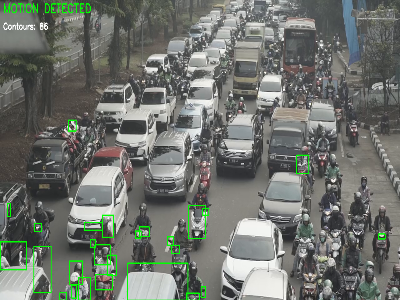

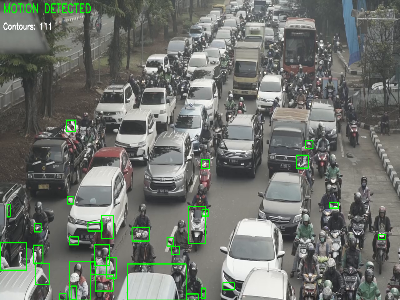

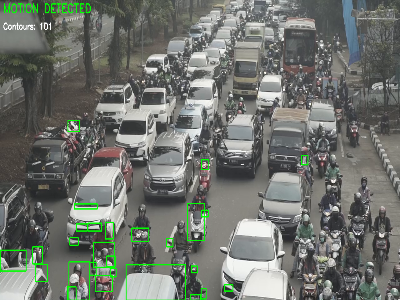

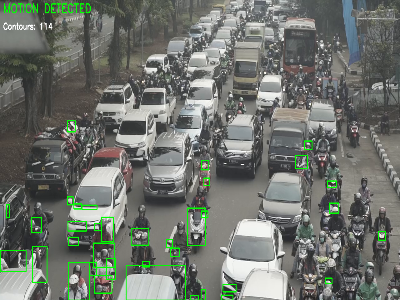

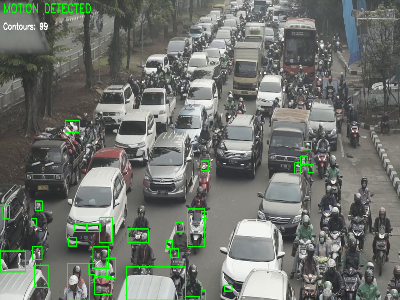

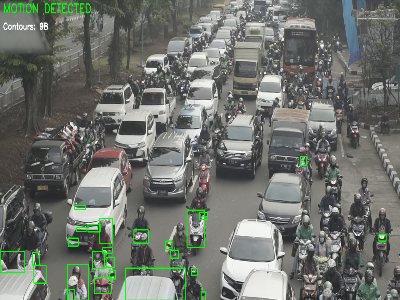

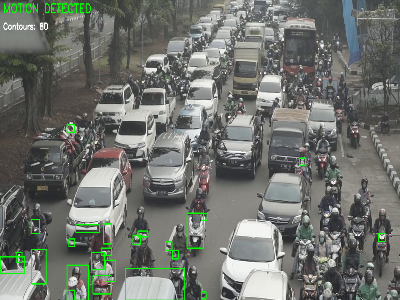

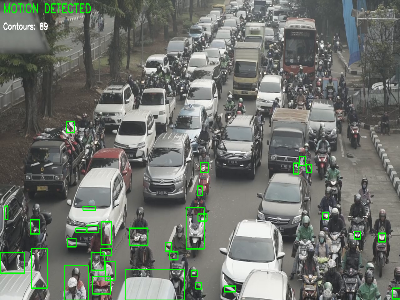

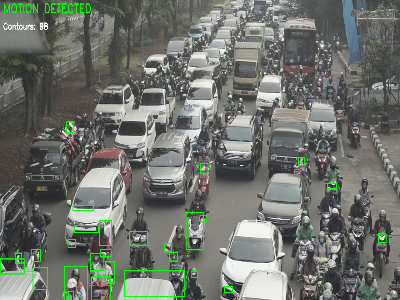

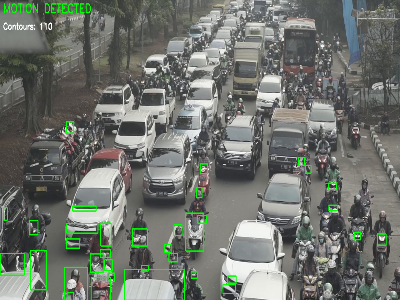

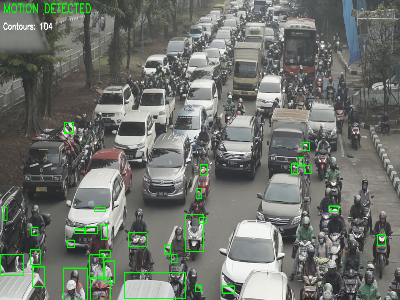

In [3]:
from google.colab import files
uploaded = files.upload()

import cv2
import numpy as np
from google.colab.patches import cv2_imshow

video_path = list(uploaded.keys())[0]
cap = cv2.VideoCapture(video_path)

if not cap.isOpened():
    print("Error: Could not open video file")
else:
    ret, first_frame = cap.read()

    if not ret:
        print("Error: Could not read video")
    else:
        prev_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
        prev_gray = cv2.GaussianBlur(prev_gray, (15, 15), 0)

        frame_count = 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            gray = cv2.GaussianBlur(gray, (15, 15), 0)

            frame_diff = cv2.absdiff(prev_gray, gray)

            thresh = cv2.threshold(frame_diff, 15, 255, cv2.THRESH_BINARY)[1]
            thresh = cv2.dilate(thresh, None, iterations=3)

            contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

            motion_detected = False

            for contour in contours:
                if cv2.contourArea(contour) > 200:
                    motion_detected = True
                    x, y, w, h = cv2.boundingRect(contour)
                    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

            status = "MOTION DETECTED" if motion_detected else "No Motion"
            color = (0, 255, 0) if motion_detected else (0, 0, 255)

            cv2.putText(frame, status, (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2)

            cv2.putText(frame, f"Contours: {len(contours)}", (10, 70),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

            frame = cv2.resize(frame, (400, 300))

            cv2_imshow(frame)

            prev_gray = gray

            frame_count += 1

            if frame_count > 10:
                break

        cap.release()